In [18]:
from pathlib import Path

data_dir = Path("/Users/nizam/Projects/crop-disease-detector/data/apple_raw")

classes = sorted(folder.name for folder in data_dir.iterdir() if folder.is_dir())

print("Classes:")
for class_name in classes:
    print("-", class_name)

Classes:
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy


In [19]:
for class_name in classes:
    class_path = data_dir / class_name
    image_count = len(list(class_path.glob("*.*")))
    print(f"{class_name}: {image_count} images")

Apple___Apple_scab: 630 images
Apple___Black_rot: 621 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 1645 images


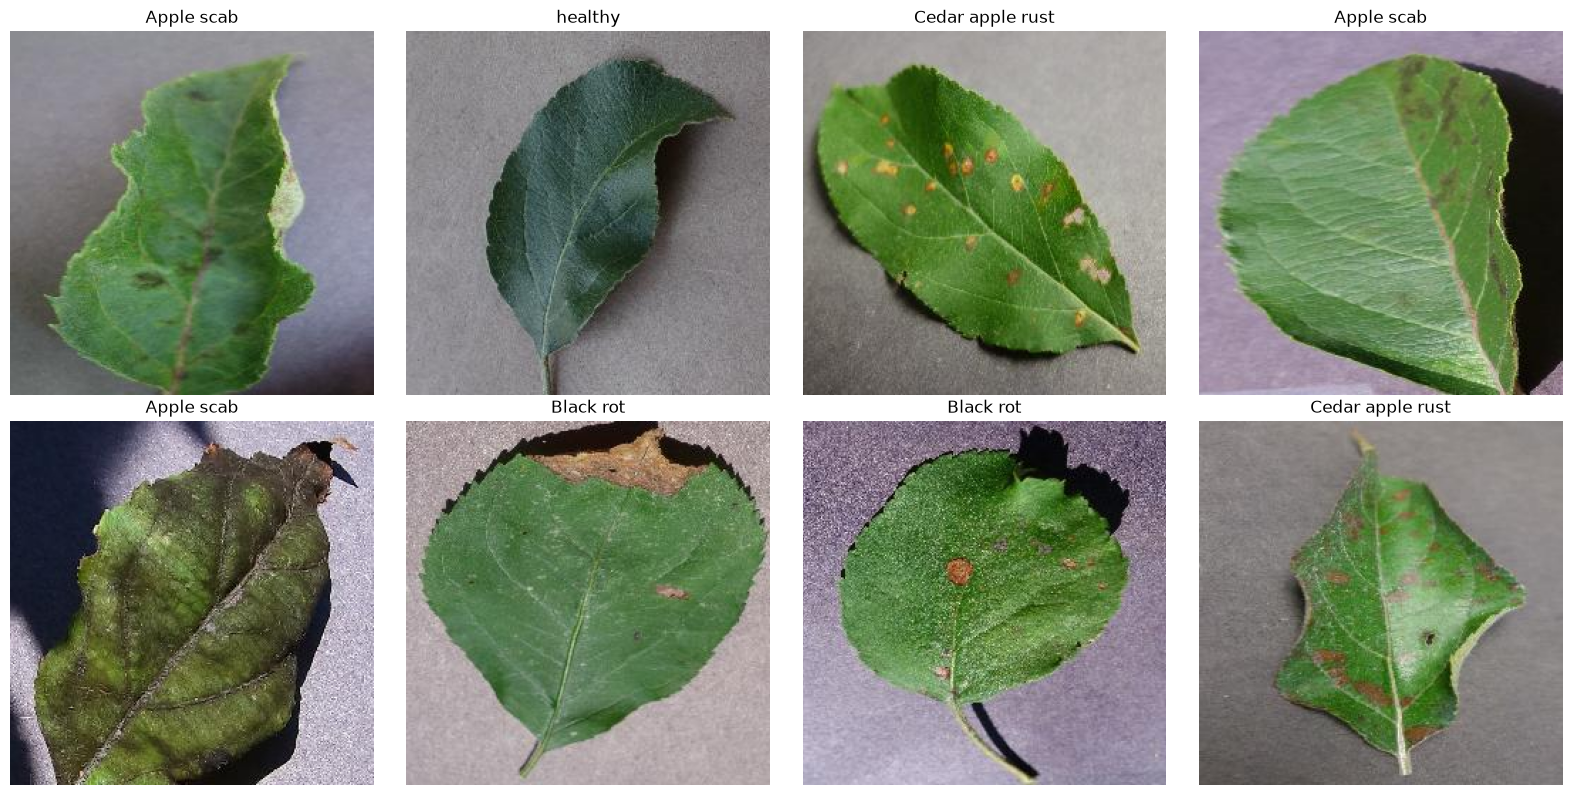

In [20]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax in axes.flat:
    class_name = random.choice(classes)
    class_path = data_dir / class_name

    image_path = random.choice(list(class_path.glob("*.*")))
    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_name.replace("Apple___", "").replace("_", " "))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
from pathlib import Path
import random
import shutil

source_dir = Path("/Users/nizam/Projects/crop-disease-detector/data/apple_raw")
split_dir = Path("/Users/nizam/Projects/crop-disease-detector/data/split")

random.seed(42)  # makes the split reproducible

# Safe to rerun: it removes only the generated split folder
if split_dir.exists():
    shutil.rmtree(split_dir)

split_ratios = {
    "train": 0.70,
    "val": 0.15,
    "test": 0.15
}

image_extensions = {".jpg", ".jpeg", ".png"}

for class_dir in source_dir.iterdir():
    if not class_dir.is_dir():
        continue

    images = [
        path for path in class_dir.iterdir()
        if path.suffix.lower() in image_extensions
    ]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * split_ratios["train"])
    val_end = train_end + int(total * split_ratios["val"])

    split_images = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split_name, image_list in split_images.items():
        output_folder = split_dir / split_name / class_dir.name
        output_folder.mkdir(parents=True, exist_ok=True)

        for image_path in image_list:
            shutil.copy2(image_path, output_folder / image_path.name)

        print(f"{split_name:5} | {class_dir.name:30} | {len(image_list)} images")

train | Apple___Cedar_apple_rust       | 192 images
val   | Apple___Cedar_apple_rust       | 41 images
test  | Apple___Cedar_apple_rust       | 42 images
train | Apple___Apple_scab             | 441 images
val   | Apple___Apple_scab             | 94 images
test  | Apple___Apple_scab             | 95 images
train | Apple___Black_rot              | 434 images
val   | Apple___Black_rot              | 93 images
test  | Apple___Black_rot              | 94 images
train | Apple___healthy                | 1151 images
val   | Apple___healthy                | 246 images
test  | Apple___healthy                | 248 images


In [22]:
for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}")
    split_path = split_dir / split_name

    for class_dir in sorted(split_path.iterdir()):
        count = len(list(class_dir.glob("*.*")))
        print(f"{class_dir.name}: {count}")
        


TRAIN
Apple___Apple_scab: 441
Apple___Black_rot: 434
Apple___Cedar_apple_rust: 192
Apple___healthy: 1151

VAL
Apple___Apple_scab: 94
Apple___Black_rot: 93
Apple___Cedar_apple_rust: 41
Apple___healthy: 246

TEST
Apple___Apple_scab: 95
Apple___Black_rot: 94
Apple___Cedar_apple_rust: 42
Apple___healthy: 248


In [23]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Using device:", device)
print("PyTorch version:", torch.__version__)


Using device: mps
PyTorch version: 2.13.0


In [24]:
image_size = 128
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(split_dir / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(split_dir / "val", transform=evaluation_transform)
test_dataset = datasets.ImageFolder(split_dir / "test", transform=evaluation_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Class mapping:", train_dataset.class_to_idx)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Class mapping: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3}
Training batches: 70
Validation batches: 15
Test batches: 15


In [25]:
from pathlib import Path

split_dir = Path("/Users/nizam/Projects/crop-disease-detector/data/split")

print("Split folder exists:", split_dir.exists())

Split folder exists: True


In [26]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

split_dir = Path("/Users/nizam/Projects/crop-disease-detector/data/split")
model_path = Path("/Users/nizam/Projects/crop-disease-detector/models/custom_cnn_best.pth")

print("Using:", device)
print("Saved model exists:", model_path.exists())

Using: mps
Saved model exists: True


In [27]:
import torch.nn as nn

num_classes = len(train_dataset.classes)

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Input: 3 × 128 × 128
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 × 64 × 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 × 32 × 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 × 16 × 16

            nn.AdaptiveAvgPool2d((1, 1))  # 128 × 1 × 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, images):
        features = self.features(images)
        predictions = self.classifier(features)
        return predictions

model = CustomCNN(num_classes=num_classes).to(device)

print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [28]:
from pathlib import Path
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
best_val_accuracy = 0.0

model_path = Path("/Users/nizam/Projects/crop-disease-detector/models/custom_cnn_best.pth")

for epoch in range(epochs):
    # ----- Training -----
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_images_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_images_total += labels.size(0)

    train_loss = train_loss_total / train_images_total
    train_accuracy = train_correct / train_images_total

    # ----- Validation -----
    model.eval()
    val_loss_total = 0
    val_correct = 0
    val_images_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_images_total += labels.size(0)

    val_loss = val_loss_total / val_images_total
    val_accuracy = val_correct / val_images_total

    print(
        f"Epoch {epoch + 1:02}/{epochs} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_accuracy:.2%} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_accuracy:.2%}"
    )

    # Save the model only when validation accuracy improves
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": train_dataset.classes,
            "image_size": image_size
        }, model_path)

print(f"\nBest validation accuracy: {best_val_accuracy:.2%}")
print(f"Saved best model to: {model_path}")

Epoch 01/10 | Train loss: 1.1535 | Train acc: 51.17% | Val loss: 1.0513 | Val acc: 51.90%
Epoch 02/10 | Train loss: 0.9724 | Train acc: 57.26% | Val loss: 0.8214 | Val acc: 63.50%
Epoch 03/10 | Train loss: 0.7282 | Train acc: 71.06% | Val loss: 0.7149 | Val acc: 70.89%
Epoch 04/10 | Train loss: 0.6002 | Train acc: 77.10% | Val loss: 0.5544 | Val acc: 77.00%
Epoch 05/10 | Train loss: 0.5220 | Train acc: 79.22% | Val loss: 0.5194 | Val acc: 78.69%
Epoch 06/10 | Train loss: 0.4411 | Train acc: 84.67% | Val loss: 0.4748 | Val acc: 81.22%
Epoch 07/10 | Train loss: 0.3391 | Train acc: 88.41% | Val loss: 0.5078 | Val acc: 81.43%
Epoch 08/10 | Train loss: 0.3240 | Train acc: 88.10% | Val loss: 0.4109 | Val acc: 83.54%
Epoch 09/10 | Train loss: 0.2710 | Train acc: 90.98% | Val loss: 0.3507 | Val acc: 85.86%
Epoch 10/10 | Train loss: 0.2438 | Train acc: 91.52% | Val loss: 0.2932 | Val acc: 89.45%

Best validation accuracy: 89.45%
Saved best model to: /Users/nizam/Projects/crop-disease-detector/m

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Reload the best saved version, not merely the last epoch
checkpoint = torch.load(model_path, map_location=device)

best_model = CustomCNN(num_classes=len(checkpoint["classes"])).to(device)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = best_model(images)
        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())

test_accuracy = np.mean(
    np.array(true_labels) == np.array(predicted_labels)
)

print(f"Test accuracy: {test_accuracy:.2%}")

print("\nClassification report:")
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=checkpoint["classes"],
        digits=3
    )
)

Test accuracy: 89.98%

Classification report:
                          precision    recall  f1-score   support

      Apple___Apple_scab      0.817     0.895     0.854        95
       Apple___Black_rot      0.985     0.702     0.820        94
Apple___Cedar_apple_rust      0.837     0.976     0.901        42
         Apple___healthy      0.923     0.964     0.943       248

                accuracy                          0.900       479
               macro avg      0.890     0.884     0.880       479
            weighted avg      0.907     0.900     0.897       479



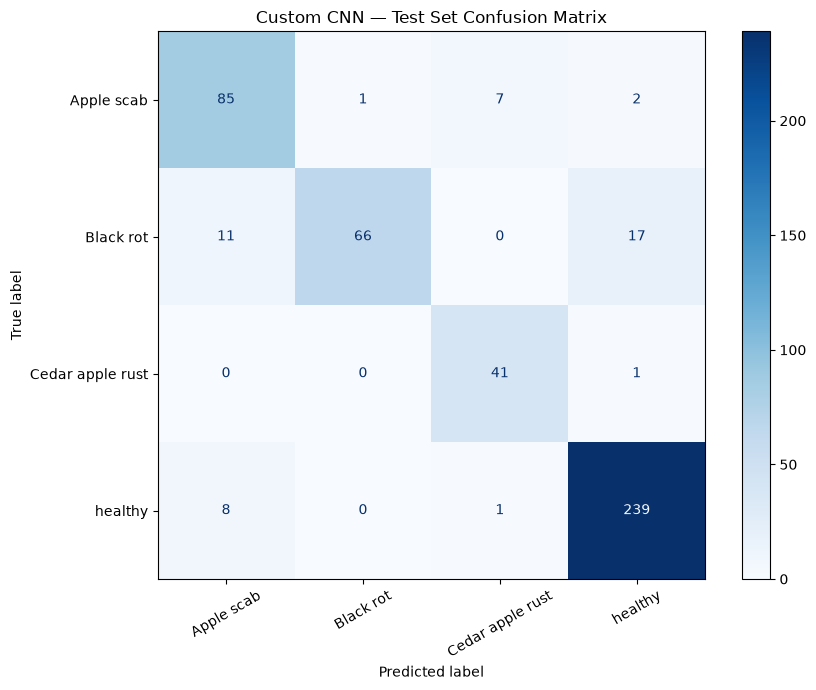

In [30]:
matrix = confusion_matrix(true_labels, predicted_labels)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=[
        name.replace("Apple___", "").replace("_", " ")
        for name in checkpoint["classes"]
    ]
)

fig, ax = plt.subplots(figsize=(9, 7))
display.plot(ax=ax, cmap="Blues", xticks_rotation=30)
plt.title("Custom CNN — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

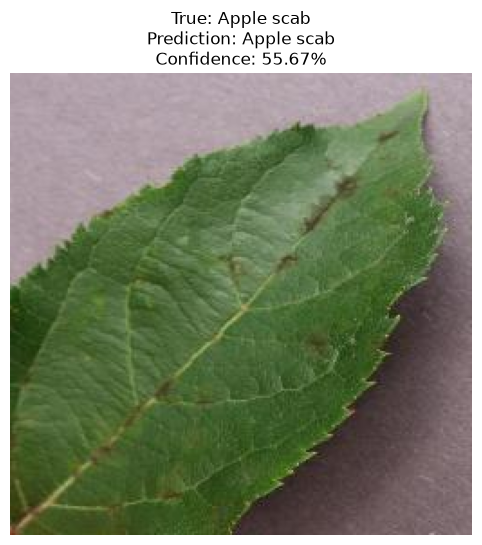

In [31]:
import random
from PIL import Image

index = random.randrange(len(test_dataset))

image_path, true_label_index = test_dataset.samples[index]
image = Image.open(image_path).convert("RGB")

input_tensor = evaluation_transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = best_model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)[0]
    predicted_label_index = probabilities.argmax().item()
    confidence = probabilities[predicted_label_index].item()

true_label = checkpoint["classes"][true_label_index]
predicted_label = checkpoint["classes"][predicted_label_index]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"True: {true_label.replace('Apple___', '').replace('_', ' ')}\n"
    f"Prediction: {predicted_label.replace('Apple___', '').replace('_', ' ')}\n"
    f"Confidence: {confidence:.2%}"
)
plt.show()